In [1]:
import numpy as np 
import pandas as pd 
import random
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import torch
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
DataSetListingPath = '/kaggle/input/datasets/organizations/airbnb/seattle/listings.csv'
DataSetReviewsPath = '/kaggle/input/datasets/organizations/airbnb/seattle/reviews.csv'
df_reviews = pd.read_csv(DataSetReviewsPath)
df_listings = pd.read_csv(DataSetListingPath)

In [3]:
df_reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,7202016,38917982,2015-07-19,28943674,Bianca,Cute and cozy place. Perfect location to every...
1,7202016,39087409,2015-07-20,32440555,Frank,Kelly has a great room in a very central locat...
2,7202016,39820030,2015-07-26,37722850,Ian,"Very spacious apartment, and in a great neighb..."
3,7202016,40813543,2015-08-02,33671805,George,Close to Seattle Center and all it has to offe...
4,7202016,41986501,2015-08-10,34959538,Ming,Kelly was a great host and very accommodating ...


In [4]:
df_reviews.shape

(84849, 6)

In [5]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84849 entries, 0 to 84848
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   listing_id     84849 non-null  int64 
 1   id             84849 non-null  int64 
 2   date           84849 non-null  object
 3   reviewer_id    84849 non-null  int64 
 4   reviewer_name  84849 non-null  object
 5   comments       84831 non-null  object
dtypes: int64(3), object(3)
memory usage: 3.9+ MB


In [6]:
df_reviews['listing_id'].nunique()

3191

In [7]:
listings_subset = df_listings[['id', 'review_scores_rating']].copy()
reviews_subset = df_reviews[['listing_id', 'comments']].copy()

In [8]:
listings_subset.isnull().sum()

id                        0
review_scores_rating    647
dtype: int64

In [9]:
median_rating = listings_subset['review_scores_rating'].median()
listings_subset['review_scores_rating'] = listings_subset['review_scores_rating'].fillna(median_rating)

listings_subset.isnull().sum()


id                      0
review_scores_rating    0
dtype: int64

In [10]:
reviews_subset.isnull().sum()
reviews_subset = reviews_subset.dropna(subset=['comments'])
reviews_subset.isnull().sum()

listing_id    0
comments      0
dtype: int64

In [11]:
df_merged = pd.merge(
    reviews_subset, 
    listings_subset, 
    left_on='listing_id', 
    right_on='id', 
    how='inner'
)

In [12]:
df_merged.head()
df_merged = df_merged.drop(columns=['id','listing_id'])
df_merged.shape

(84831, 2)

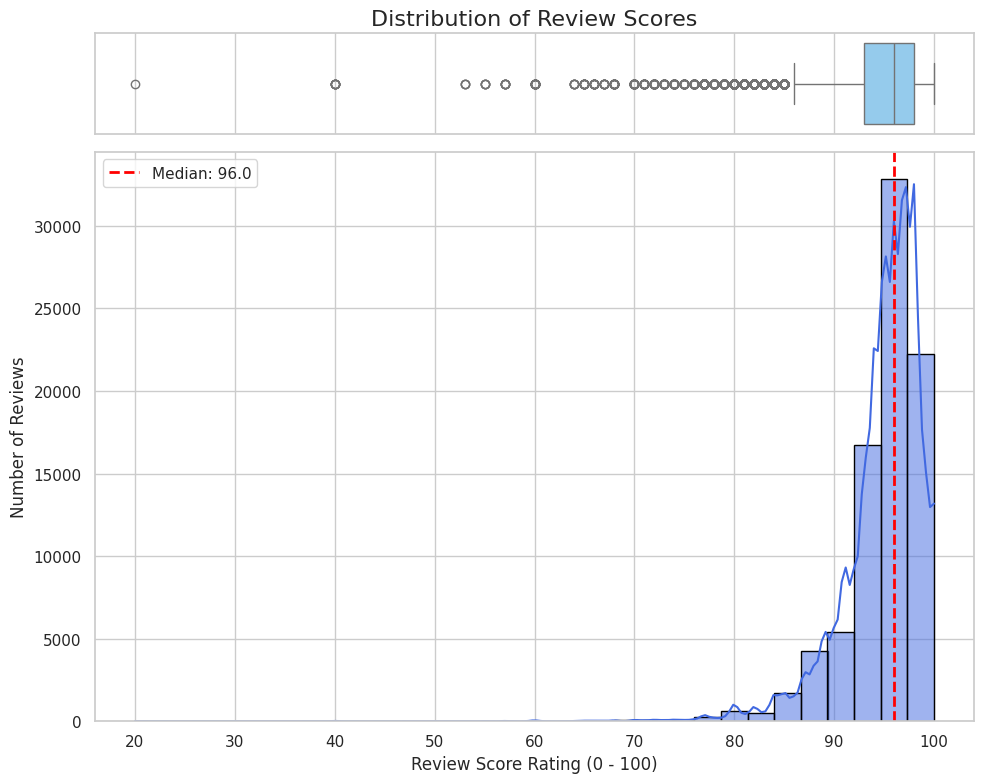

--- Score Statistics ---
count    84831.000000
mean        94.896783
std          4.084441
min         20.000000
25%         93.000000
50%         96.000000
75%         98.000000
max        100.000000
Name: review_scores_rating, dtype: float64
Scores strictly less than 95: 29725 (35.04%)
Scores 95 and greater:      55106 (64.96%)


In [13]:
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (Histogram on top, Boxplot on bottom)
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10, 8), gridspec_kw={"height_ratios": (.15, .85)})

# 1. Top Subplot: Boxplot (Great for spotting outliers)
sns.boxplot(x=df_merged['review_scores_rating'], ax=ax_box, color='lightskyblue')
ax_box.set(xlabel='') # Hide the x-label for the top plot
ax_box.set_title('Distribution of Review Scores', fontsize=16)

# 2. Bottom Subplot: Histogram with KDE (Density curve)
sns.histplot(df_merged['review_scores_rating'], bins=30, kde=True, ax=ax_hist, color='royalblue', edgecolor='black')
ax_hist.set_xlabel('Review Score Rating (0 - 100)', fontsize=12)
ax_hist.set_ylabel('Number of Reviews', fontsize=12)

# Add a vertical line showing the median score
median_score = df_merged['review_scores_rating'].median()
ax_hist.axvline(median_score, color='red', linestyle='--', linewidth=2, label=f'Median: {median_score}')
ax_hist.legend()

plt.tight_layout()
plt.show()

# Print some quick summary statistics
print("--- Score Statistics ---")
print(df_merged['review_scores_rating'].describe())
below_95 = (df_merged['review_scores_rating'] < 95).sum()
above_or_equal_95 = (df_merged['review_scores_rating'] >= 95).sum()

# Calculate the percentages for context
total_reviews = len(df_merged)
percent_below = (below_95 / total_reviews) * 100
percent_above = (above_or_equal_95 / total_reviews) * 100

print(f"Scores strictly less than 95: {below_95} ({percent_below:.2f}%)")
print(f"Scores 95 and greater:      {above_or_equal_95} ({percent_above:.2f}%)")



In [14]:
df_merged['sentiment_label'] = (df_merged['review_scores_rating'] >= 95).astype(int)

df_merged = df_merged.drop(columns=['review_scores_rating'])

print(df_merged.head())

                                            comments  sentiment_label
0  Cute and cozy place. Perfect location to every...                1
1  Kelly has a great room in a very central locat...                1
2  Very spacious apartment, and in a great neighb...                1
3  Close to Seattle Center and all it has to offe...                1
4  Kelly was a great host and very accommodating ...                1


In [15]:
def clean_text(text):
    text = re.sub(r"http\S+", "", text)  
    text = re.sub(r"@\w+", "", text)     
    text = re.sub(r"#\w+", "", text)     
    text = re.sub(r"[^\w\s.,!?]", "", text)  
    return text

df_merged["comments"] = df_merged["comments"].apply(clean_text)
df_merged.head()

,comments,sentiment_label
0,Cute and cozy place. Perfect location to every...,1
1,Kelly has a great room in a very central locat...,1
2,"Very spacious apartment, and in a great neighb...",1
3,Close to Seattle Center and all it has to offe...,1
4,Kelly was a great host and very accommodating ...,1


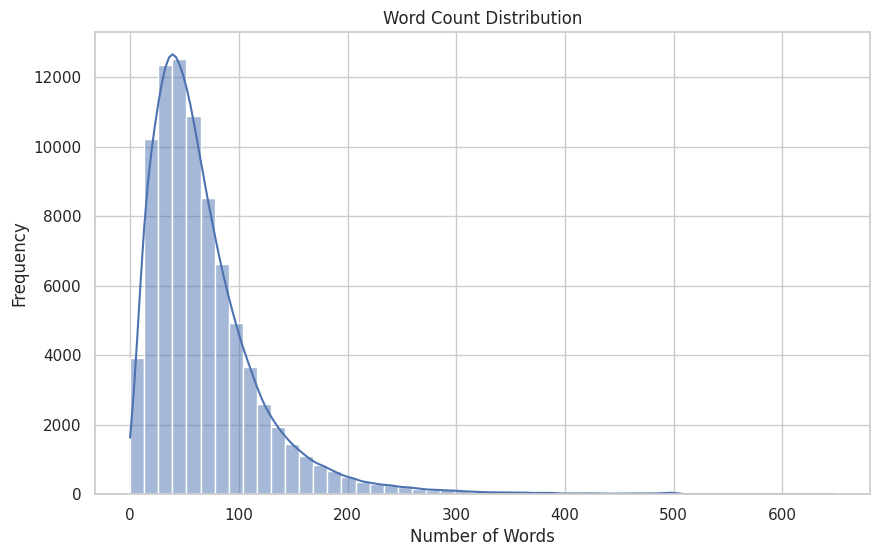

90%: 130.0
95%: 167.0
99%: 271.0


In [16]:
df_merged["word_count"] = df_merged["comments"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_merged["word_count"], bins=50, kde=True)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

print("90%:", df_merged["word_count"].quantile(0.90))
print("95%:", df_merged["word_count"].quantile(0.95))
print("99%:", df_merged["word_count"].quantile(0.99))

In [17]:
df_merged.drop(columns=["word_count"], inplace=True)
df_merged.head()

,comments,sentiment_label
0,Cute and cozy place. Perfect location to every...,1
1,Kelly has a great room in a very central locat...,1
2,"Very spacious apartment, and in a great neighb...",1
3,Close to Seattle Center and all it has to offe...,1
4,Kelly was a great host and very accommodating ...,1


In [18]:
df_hf = df_merged.rename(columns={"comments": "text", "sentiment_label": "label"})


train_df, temp_df = train_test_split(df_hf, test_size=0.3, random_state=42, stratify=df_hf['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

In [19]:
hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})
hf_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 59381
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12725
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12725
    })
})

In [20]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=200)

tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/59381 [00:00<?, ? examples/s]

Map:   0%|          | 0/12725 [00:00<?, ? examples/s]

Map:   0%|          | 0/12725 [00:00<?, ? examples/s]

In [21]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


training_args = TrainingArguments(
    output_dir="/kaggle/working/airbnb_sentiment_model",
    eval_strategy="epoch",           
    save_strategy="epoch",           
    logging_strategy="epoch",        
    learning_rate=2e-5,
    per_device_train_batch_size=32, 
    per_device_eval_batch_size=32,
    num_train_epochs=5,              
    weight_decay=0.01,
    fp16=True,                    
    load_best_model_at_end=True,    
    metric_for_best_model="loss",    
    greater_is_better=False,         
    report_to="none"              
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)] 
)


trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,1.004638,0.833038
2,0.764461,0.784487
3,0.661389,0.800783


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2784, training_loss=0.8101625771358095, metrics={'train_runtime': 1795.0014, 'train_samples_per_second': 165.407, 'train_steps_per_second': 2.585, 'total_flos': 9218023358896800.0, 'train_loss': 0.8101625771358095, 'epoch': 3.0})

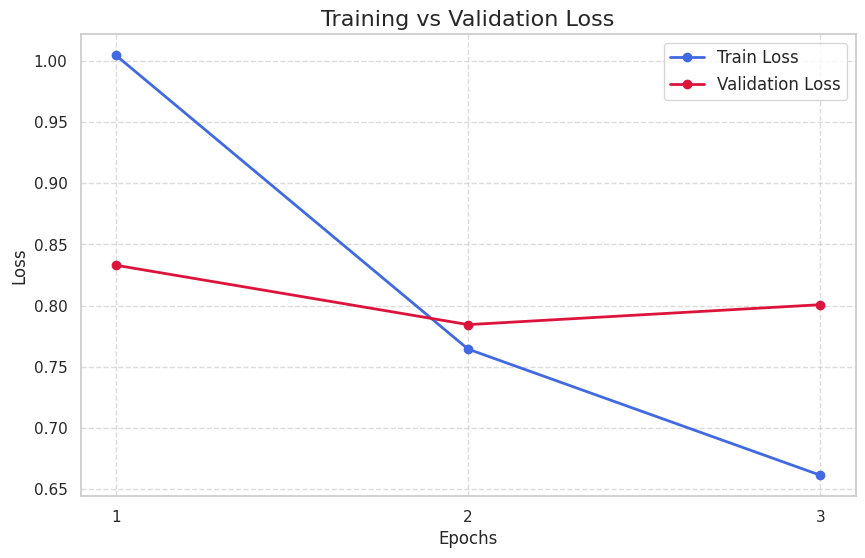

In [23]:
# 1. Extract the logs safely
log_history = trainer.state.log_history

# Use list comprehensions for safe, clean extraction
train_loss = [log['loss'] for log in log_history if 'loss' in log]
val_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
epochs = [log['epoch'] for log in log_history if 'eval_loss' in log]

# Ensure we only plot where we have matching data points
min_len = min(len(train_loss), len(val_loss))
epochs = epochs[:min_len]
train_loss = train_loss[:min_len]
val_loss = val_loss[:min_len]

# 2. Plotting the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Train Loss', marker='o', color='royalblue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', marker='o', color='crimson', linewidth=2)

plt.title('Training vs Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs) # Force x-axis to show whole epoch numbers
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Running predictions on the Test Set...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



--- Final Classification Report ---
                       precision    recall  f1-score   support

Needs Improvement (0)       0.78      0.63      0.70      4459
         Positive (1)       0.82      0.90      0.86      8266

             accuracy                           0.81     12725
            macro avg       0.80      0.77      0.78     12725
         weighted avg       0.80      0.81      0.80     12725



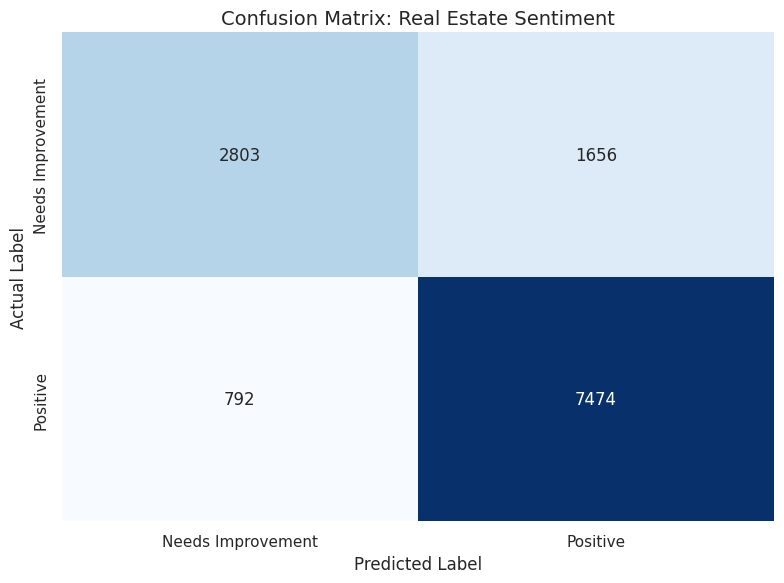

In [24]:
print("Running predictions on the Test Set...")
test_predictions = trainer.predict(tokenized_datasets["test"])

# Convert raw logits (math output) into 0 or 1 labels
y_pred = np.argmax(test_predictions.predictions, axis=1)
y_true = tokenized_datasets["test"]["label"]

# 2. Print Classification Report
print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=["Needs Improvement (0)", "Positive (1)"]))

# 3. Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Needs Improvement", "Positive"], 
            yticklabels=["Needs Improvement", "Positive"],
            cbar=False) # Turned off colorbar for a cleaner look

plt.title('Confusion Matrix: Real Estate Sentiment', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
import shutil

# 1. Define the folder name
save_directory = "./my_real_estate_distilbert"

# 2. Tell the Trainer to save the final, best model weights into the folder
trainer.save_model(save_directory)

# 3. Save the Tokenizer! 
# (Since you didn't pass 'tokenizer=tokenizer' inside your Trainer() arguments above, 
# you still must save it manually so your local PC knows how to read the words)
tokenizer.save_pretrained(save_directory)

# 4. Zip the folder into a single file
shutil.make_archive("my_real_estate_distilbert", 'zip', save_directory)



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

'/kaggle/working/my_real_estate_distilbert.zip'

In [32]:
from IPython.display import FileLink
FileLink(r'my_real_estate_distilbert.zip')

/kaggle/working/my_real_estate_distilbert.zip

In [33]:
df_merged.to_csv('Review_Cleaned.csv', index = False)